In [83]:
#IMPORTING THE REQUIRED LIBRARIES!!
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [84]:
#IMPORTING THE DATA NEEDED FOR ANALYSIS (DATASETS)
orders = pd.read_csv("../Data/blinkit_orders.csv") 
order_items = pd.read_csv("../Data/blinkit_order_items.csv")
products = pd.read_csv("../Data/blinkit_products.csv")
customers = pd.read_csv("../Data/blinkit_customers.csv") 
feedback = pd.read_csv("../Data/blinkit_customer_feedback.csv")
inventory = pd.read_csv("../Data/blinkit_inventory.csv")
delivery = pd.read_csv("../Data/blinkit_delivery_performance.csv")
marketing = pd.read_csv("../Data/blinkit_marketing_performance.csv")

In [85]:
#Displaying Contents of the Datasets (DATA PREVIEW)
orders.head()
customers.head()
products.head()
order_items.head()


,order_id,product_id,quantity,unit_price
0,1961864118,642612,3,517.03
1,1549769649,378676,1,881.42
2,9185164487,741341,2,923.84
3,9644738826,561860,1,874.78
4,5427684290,602241,2,976.55


In [86]:
#FEATURES ENGINEERING-------------------------------------------------------------------------------------------------------------------

In [87]:
#MERGING DATA
sales_data = pd.merge(order_items, products,on="product_id") #Merge transaction data with product information
print(sales_data)

        order_id  product_id  quantity  unit_price    product_name  \
0     1961864118      642612         3      517.03      Pet Treats   
1     1549769649      378676         1      881.42    Orange Juice   
2     9185164487      741341         2      923.84            Eggs   
3     9644738826      561860         1      874.78    Orange Juice   
4     5427684290      602241         2      976.55            Nuts   
...          ...         ...       ...         ...             ...   
4995  1669690997      925482         3      475.04  Frozen Biryani   
4996  8340761903      124290         2       39.65          Lotion   
4997  5936301790      491314         3      973.44       Ice Cream   
4998  5710579377      319388         2      657.80    Orange Juice   
4999  2494813730      136533         1      826.21            Eggs   

                   category                        brand   price      mrp  \
0                  Pet Care                 Pillay-Ahuja  517.03   795.43   
1    

In [88]:
#BUSINESS QUESTIONS-----------------------------------------------------------------------------------------------------------------------
#Ques.1 : What is the total revenue generated??

In [89]:
#Total Revenue is unit price of each product multiplied by the amount/quantity of product order
order_items["Revenue"] = order_items["quantity"] * order_items["unit_price"]

In [90]:
order_items.head()

,order_id,product_id,quantity,unit_price,Revenue
0,1961864118,642612,3,517.03,1551.09
1,1549769649,378676,1,881.42,881.42
2,9185164487,741341,2,923.84,1847.68
3,9644738826,561860,1,874.78,874.78
4,5427684290,602241,2,976.55,1953.10


In [91]:
total_revenue = order_items["Revenue"].sum() #Total Revenue  = summation of revenue generated from each order

print(f"Total Revenue: ₹{total_revenue:,.2f}")

Total Revenue: ₹4,972,415.43


In [ ]:
#Business Insight #1 : Blinkit generated a total revenue of nearly ₹49.72 lakh from available transaction dataset in a month.

In [ ]:
#Ques.2 : What are the Top Products, Top Categories?

#Top Products/Categories are those products or category of product that generate the maximum amount of revenue to the company
# We will filter out Top 10 Products and Product Category that benefit the company most

In [94]:

new_salesdata = pd.merge(sales_data, order_items, on = "product_id")
# print(new_salesdata.columns)

# Grouping together sales and product name to calculate total revenue generated by each product i.e. Product Revenue

product_revenue = new_salesdata.groupby("product_name")["Revenue"].sum()

# Sorting products revneue in decreasing order

product_revenue = product_revenue.sort_values(ascending=False)

# Display Top 10 revenue-generating products

top_products = product_revenue.head(10)

print(top_products)

print("----------------------------------")

#Grouping together sales and product category to calculate total revenu generated by each product category i.e. Category Revenue
category_revenue = new_salesdata.groupby("category")["Revenue"].sum()

# Sorting category revneue in decreasing order
category_revenue = category_revenue.sort_values(ascending=False)

#Display Top 10 revenue-generating categories
top_category = category_revenue.head(10)
print(top_category)


product_name
Vitamins          5237008.48
Pet Treats        4964343.28
Cough Syrup       4566211.78
Toilet Cleaner    4139648.35
Bread             4066681.50
Cat Food          3676711.81
Dish Soap         3490926.32
Baby Food         3421084.13
Baby Wipes        3364926.62
Pain Reliever     2880677.40
Name: Revenue, dtype: float64
----------------------------------
category
Dairy & Breakfast       12960005.23
Pharmacy                12683897.66
Fruits & Vegetables     11212682.50
Pet Care                10938182.06
Household Care           8746018.62
Baby Care                7893127.51
Personal Care            7368410.76
Snacks & Munchies        7263560.70
Grocery & Staples        7088864.72
Cold Drinks & Juices     7076102.90
Name: Revenue, dtype: float64


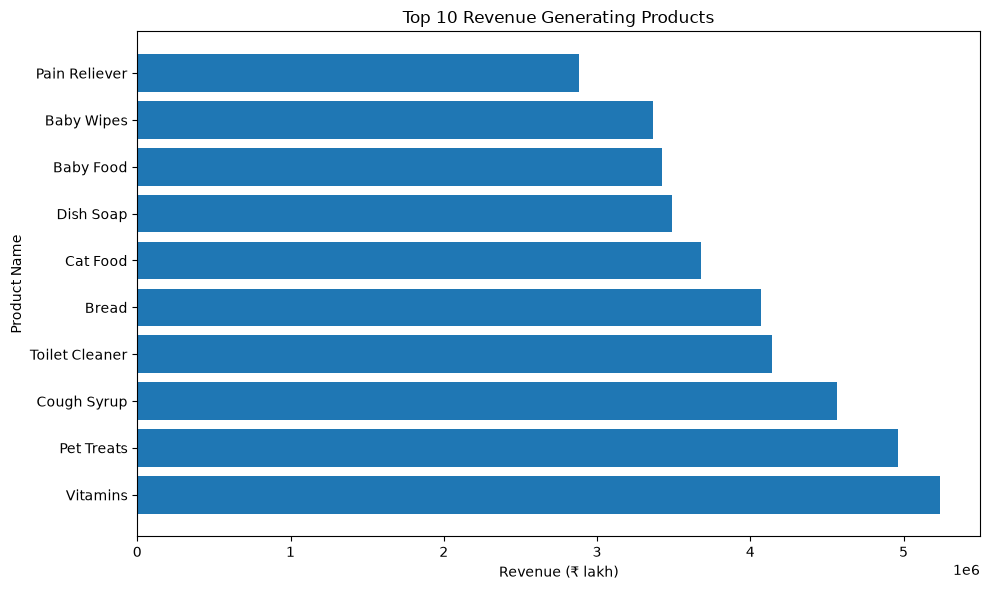

In [ ]:
# Visualization for Top 10 Revenue Generating Products
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(
    top_products.index,
    top_products.values
)

plt.title("Top 10 Revenue Generating Products")
plt.xlabel("Revenue (₹ lakh)")
plt.ylabel("Product Name")

plt.tight_layout()
plt.show()

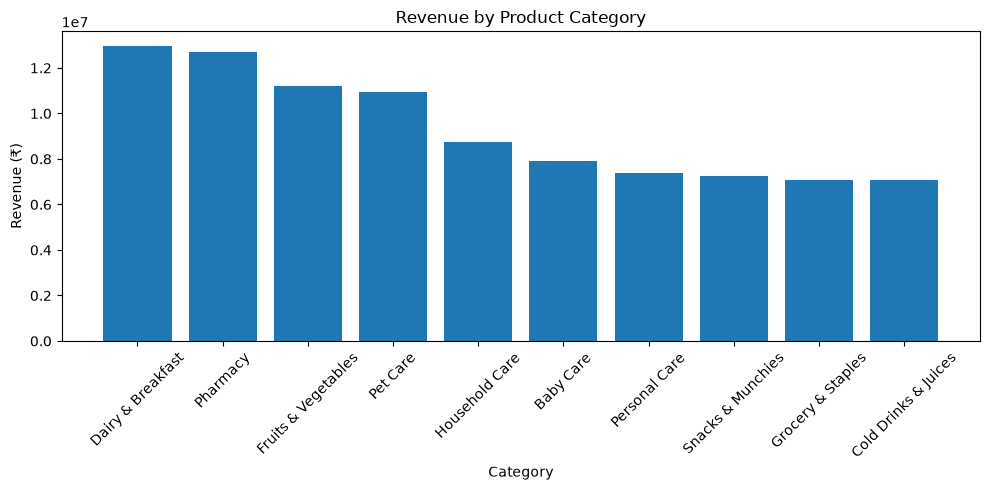

In [96]:
# Visualization for Top Revenue Categories
plt.figure(figsize=(10,5))

plt.bar(
    top_category.index,
    top_category.values
)

plt.title("Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Revenue (₹)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [97]:
# #Business Insights: The tables above identifies the top 10 revenue-generating products and product categories and the revenue generated by them

# These products contribute significantly to overall business revenue and should receive priority in inventory planning, promotions, discounts and stock availability.

#  High-performing categories should receive greater inventory allocation and promotions, while low-performing categories may require discounts, marketing, or assortment optimization.

In [98]:
#Ques.3:  Which products have the highest demand?
# The objective is to analyze customer purchasing behaviour and deduce which products are selling highest number of units?


In [99]:

# Merge products and order_items table to get which product (product_id ) is ordered the how many times (quantity)
product_summary = pd.merge(products, order_items, on = "product_id")
print(product_summary.head())

# Grouping product name and quanity together
demand_products = product_summary.groupby("product_name")["quantity"].sum()
demand_products = demand_products.sort_values(ascending = False)

# Display the products with Most Demand
print(demand_products.head(10))

   product_id product_name             category       brand   price      mrp  \
0      153019       Onions  Fruits & Vegetables  Aurora LLC  947.95  1263.93   
1      153019       Onions  Fruits & Vegetables  Aurora LLC  947.95  1263.93   
2      153019       Onions  Fruits & Vegetables  Aurora LLC  947.95  1263.93   
3      153019       Onions  Fruits & Vegetables  Aurora LLC  947.95  1263.93   
4      153019       Onions  Fruits & Vegetables  Aurora LLC  947.95  1263.93   

   margin_percentage  shelf_life_days  min_stock_level  max_stock_level  \
0               25.0                3               13               88   
1               25.0                3               13               88   
2               25.0                3               13               88   
3               25.0                3               13               88   
4               25.0                3               13               88   

     order_id  quantity  unit_price  Revenue  
0  7169974633        

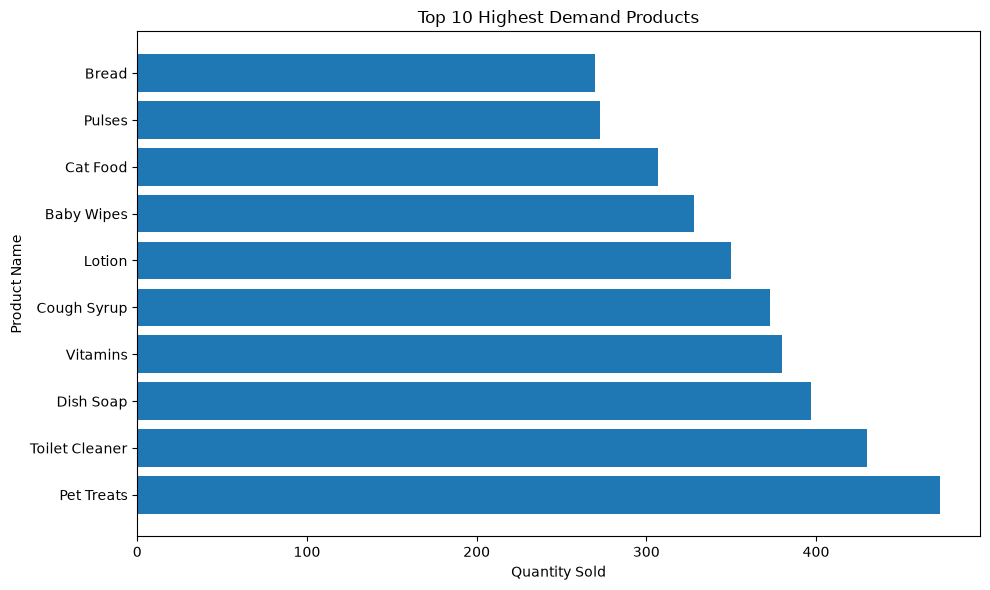

In [100]:
#Visualization For Highest Demand Products
plt.figure(figsize=(10,6))

plt.barh(
    demand_products.head(10).index,
    demand_products.head(10).values
)

plt.title("Top 10 Highest Demand Products")
plt.xlabel("Quantity Sold")
plt.ylabel("Product Name")

plt.tight_layout()
plt.show()

In [101]:
#Business Insights: The chart highlights the products with the highest customer demand.
# Daily-use household and grocery items dominate the list indicating consistent customer purchasing behavior.

# Blinkit should prioritize inventory planning for these products to minimize stock-outs and ensure product availability.   

In [ ]:
#Ques.4 : Does a higher product price increase revenue, or does it reduce customer demand?

# The objective is to determine what is effect of prices on demand of products
# We will analyze a table containing most expensive and most cheap products and compare their demand (quantity)

In [103]:
# Grouping together products and it's per unit prices
prod_summary = product_summary.groupby("product_name").agg({"price":"first","quantity":"sum","Revenue":"sum"})

#sorting the product details by price and creating a list of top most expensive and cheap
exp_prod = prod_summary.sort_values(by="price", ascending=False)
print(exp_prod.head(10))
chp_prod = prod_summary.sort_values(by="price", ascending=True)
print(chp_prod.head(10))


                 price  quantity    Revenue
product_name                               
Ice Cream       973.44        98   55899.99
Cookies         951.27        97   46620.19
Soap            949.73       186  110906.63
Onions          947.95       222  138858.42
Mangoes         946.86       101   94339.05
Cola            883.44       230  132367.36
Frozen Biryani  827.77       254  111562.12
Diapers         827.44        91   52015.98
Carrots         825.46       191  120499.25
Cat Food        820.90       307  166596.39
                    price  quantity    Revenue
product_name                                  
Toothpaste          43.05       194   97911.67
Frozen Vegetables   46.62       137   59165.57
Eggs                58.59       246  137396.83
Toilet Cleaner      77.11       430  199837.48
Cheese              96.09       182   78519.56
Potatoes           127.16       230   92859.84
Cereal             154.50        86   24021.80
Detergent          193.46       251   59965.56
Pu

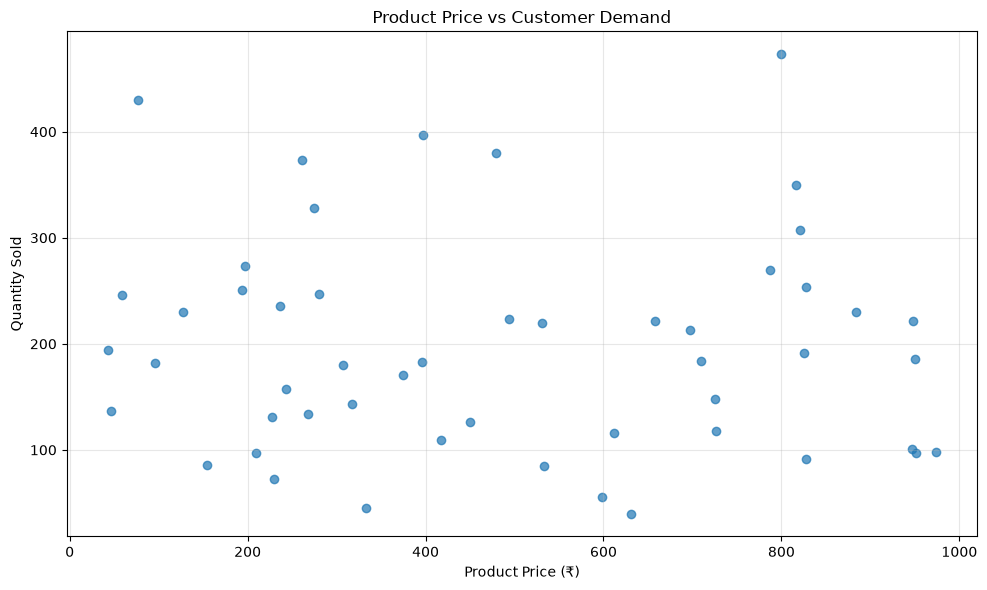

In [104]:
# Scatter Plot visualization 
plt.figure(figsize=(10,6))

plt.scatter(
    prod_summary["price"],
    prod_summary["quantity"],
    alpha=0.7
)

plt.title("Product Price vs Customer Demand")
plt.xlabel("Product Price (₹)")
plt.ylabel("Quantity Sold")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [105]:
# Business Insight: There is no strong linear relationship between product price and customer demand.
# Products across both low and high price ranges show varying sales quantities.

# While some high-priced products have relatively low demand, a few expensive products still record strong sales indicating that 
# customers are willing to pay premium prices for certain products.

# This suggests that product demand is influenced by factors beyond price such as: product category, customer preferences, and necessity.

# Blinkit should avoid making pricing decisions solely on product price , instead consider demand patterns and customer buying behaviour.

In [106]:
#Ques.5: Which products have the lowest customer demand, and what could be the possible reasons behind their poor performance?

# Identify low-performing products based on demand and revenue, then investigate possible business reasons such as:

# - High selling price
# - Low inventory availability
# - Damaged stock
# - Poor customer ratings
# - Negative customer feedback

In [107]:
# print(product_summary.head())
# print(product_summary.columns)
# Calculate total quantity sold for each product

low_demand_products = product_summary.groupby(["product_name", "product_id"]).agg({"quantity": "sum","Revenue": "sum","price": "first"}) #agg for multiple func at same point of time

# Sort by quantity sold (lowest demand first)

low_demand_products = low_demand_products.sort_values(by="quantity")

# Display bottom 10 products

print(low_demand_products.head(10))


                           quantity   Revenue   price
product_name   product_id                            
Pain Reliever  33797              9   7993.08  888.12
Onions         890623            13   4608.76  354.52
Detergent      133542            17   1164.33   68.49
Eggs           741341            19  17552.96  923.84
Pain Reliever  154179            20  11657.40  582.87
Cola           300159            21    931.35   44.35
Frozen Biryani 470449            22  18210.94  827.77
Lotion         385113            22  17960.36  816.38
Dog Food       525531            23  19115.30  831.10
Vitamins       706112            23  11012.17  478.79


In [108]:
# Business Insight: The above table identifies the 10 products with the lowest customer demand based on total quantity sold.
# Products such as Spinach, Lemonade and Milk recorded the lowest sales volume in the available transaction dataset. While some of these products also generate relatively 
# low revenue, the current analysis alone cannot determine the exact reason behind their poor performance.

# Further investigation is required to determine whether low demand is influenced by pricing, inventory availability, damaged stock, or customer satisfaction.


In [109]:
#Recommendation: These products should be investigated further before making business decisions.
# Analysis of pricing, inventory records, damaged stock and customer feedback is needed to identify the root cause of their poor performance.

In [110]:
#Business Question 5.1 : Are low-demand products expensive compared to other products?
# The objective is to determine if product pricing is reason behind poor performance of the products

In [111]:
average_price = product_summary["price"].mean()

print(f"Average Product Price : ₹{average_price:.2f}")

above_avg_priced_products = low_demand_products["price"] > average_price

print(low_demand_products[above_avg_priced_products])

low_demand_products = low_demand_products.reset_index()

Average Product Price : ₹493.16
                           quantity   Revenue   price
product_name   product_id                            
Pain Reliever  33797              9   7993.08  888.12
Eggs           741341            19  17552.96  923.84
Pain Reliever  154179            20  11657.40  582.87
Frozen Biryani 470449            22  18210.94  827.77
Lotion         385113            22  17960.36  816.38
...                             ...       ...     ...
Milk           89084             56  33534.48  598.83
Bread          880510            58  55182.94  951.43
Pain Reliever  992178            60  37945.80  632.43
Mangoes        34186             61  56464.65  925.65
Baby Food      51036             70  65212.70  931.61

[123 rows x 3 columns]


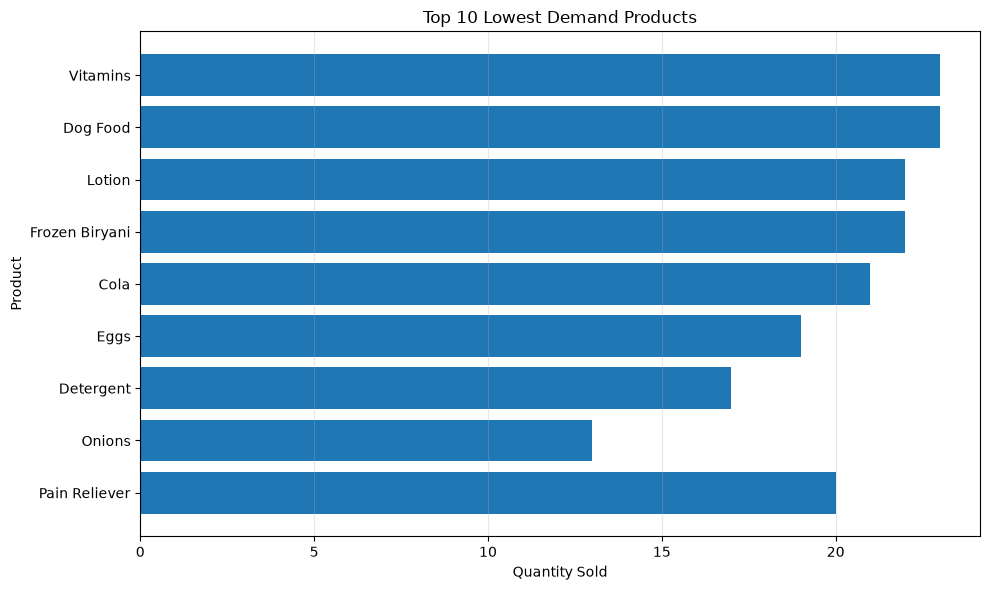

In [112]:
#Visualization for product pricing and demand
plt.figure(figsize=(10,6))

plt.barh(
    low_demand_products.head(10)["product_name"],
    low_demand_products.head(10)["quantity"]
)

plt.title("Top 10 Lowest Demand Products")
plt.xlabel("Quantity Sold")
plt.ylabel("Product")

plt.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

In [113]:
# Business Insight: The average product price in the available dataset is ₹493.16.

# Most of the low-demand products are priced above this average indicating that higher pricing could be one of the causes of low customer demand

# However, pricing alone cannot explain poor product performance.

# Further analysis of inventory availability, damaged stock and customer feedback is required before making pricing decisions.

In [114]:
# Buisness Question 5.2: Is low customer demand caused by insufficient inventory?
# The objective is to identify if insufficient stock is a reason behind lower customer demands



In [115]:

inventory_summary = inventory.groupby("product_id").agg({"stock_received": "sum","damaged_stock": "sum"}).reset_index()

inventory_summary["available_stock"] = (inventory_summary["stock_received"] - inventory_summary["damaged_stock"])

low_demand_products = (product_summary.groupby(["product_id", "product_name"]).agg({"quantity":"sum","Revenue":"sum","price":"first"}).reset_index())
stock_analysis = pd.merge(low_demand_products,inventory_summary,on="product_id")
print(stock_analysis)

stock_analysis = stock_analysis.sort_values(by="quantity")
print(stock_analysis[["product_name","quantity","Revenue","price","stock_received","damaged_stock","available_stock"]].head(10))

     product_id   product_name  quantity   Revenue   price  stock_received  \
0          4452     Baby Wipes        39   6625.32  169.88             705   
1          6405      Baby Food        34   8041.34  236.51             556   
2          9436     Toothpaste        44   3890.92   88.43             322   
3         11422       Potatoes        27   3433.32  127.16             482   
4         14145        Spinach        40  25233.60  630.84             542   
..          ...            ...       ...       ...     ...             ...   
263      970529        Diapers        45  37234.80  827.44             553   
264      990993     Chocolates        37   9756.90  263.70             446   
265      991434        Cookies        44  10455.28  237.62             535   
266      992178  Pain Reliever        60  37945.80  632.43             673   
267      993331         Pulses        23   2356.12  102.44             459   

     damaged_stock  available_stock  
0              302       

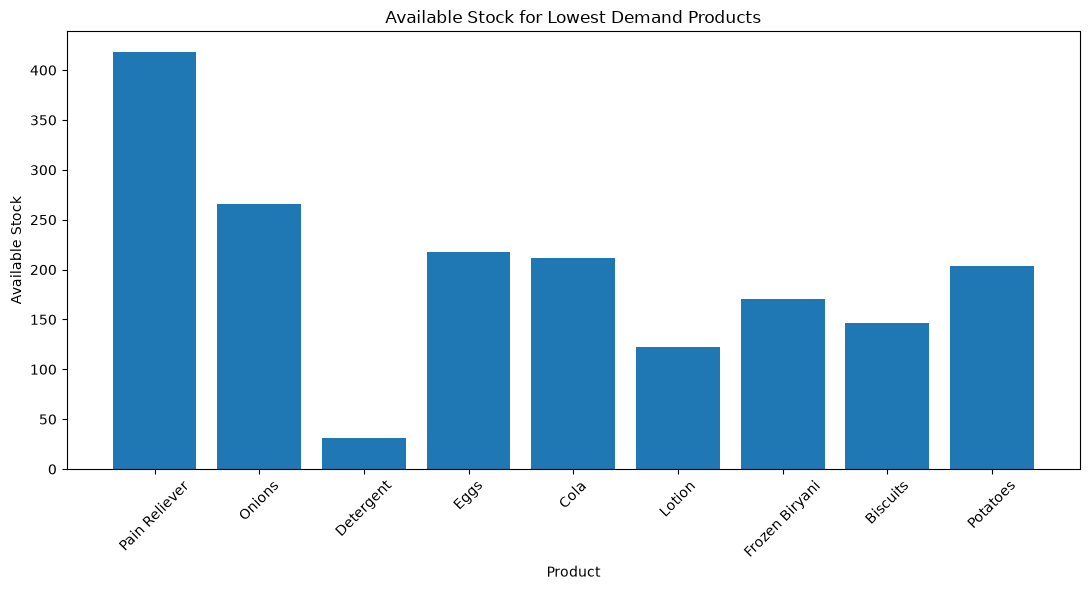

In [116]:
#Visualization for customer demand vs stock availability
stock_top = stock_analysis.sort_values("quantity").head(10)

plt.figure(figsize=(11,6))

plt.bar(
    stock_top["product_name"],
    stock_top["available_stock"]
)

plt.title("Available Stock for Lowest Demand Products")
plt.xlabel("Product")
plt.ylabel("Available Stock")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [117]:
# Business Insight: After comparing product demand with inventory availability shows that low sales are not always caused by insufficient stock.

# Several products had high available inventory despite recording very low sales, indicating weak customer demand rather than inventory shortages 
# For example, Pain Reliever (Product ID: 33797) had only 9 units sold despite having 418 units available in inventory. 
# Similarly,   Onions recorded only 13 units sold while 266 units were available. This


# However, a few products had relatively low available stock,suggesting that inventory constraints may also have contributed to lower sales.
# for e.g.-  Detergent had only 31 units available in stock while selling 17 units. In such cases, limited inventory COULD have partially restricted sales.

# Therefore, inventory alone does not explain poor product performance, and customer feedback should be analyzed next to identify additional reasons behind low demand.

In [118]:
#Business Ques 5.3: Do low-demand products receive poor customer ratings or negative feedback?
# The objective is to analyze customer feedback for products with lower demands and identify if it is a contributing factor behind lower demands

In [119]:
feedback_orders = pd.merge(feedback, order_items, on='order_id') # to connect feedback to order id
# print(feedback_orders.head(10))

feedback_product = pd.merge(feedback_orders, low_demand_products, on='product_id') #connect feedback to products
# print(feedback_product.head(10))  

product_rating = feedback_product.groupby("product_name").agg({ "rating": ["mean", "count"]})
# print(product_rating)

product_rating.columns = [ "Average Rating","Total Reviews"] #RENAMING FOR BETTER UNDERSTANDING!
product_rating = product_rating.sort_values(by='Average Rating')
print(product_rating.head(10))
product_rating = product_rating.sort_values(by = 'Average Rating')

avg_reviews = product_rating["Total Reviews"].mean()

print(f"Average Reviews per Product: {avg_reviews:.2f}")
print("------------------------------------------------------")

high_review_products = product_rating[product_rating["Total Reviews"] >= avg_reviews]

high_review_products = high_review_products.sort_values(by="Average Rating")

worst_ratings = product_rating.head(10)

print(high_review_products)

                 Average Rating  Total Reviews
product_name                                  
Instant Noodles        2.942857             35
Cereal                 3.000000             44
Cookies                3.085106             47
Nuts                   3.085714             70
Dog Food               3.103448            116
Bananas                3.111111             45
Ice Cream              3.120000             50
Lemonade               3.142857             21
Curd                   3.164384             73
Butter                 3.191781             73
Average Reviews per Product: 98.04
------------------------------------------------------
                Average Rating  Total Reviews
product_name                                 
Dog Food              3.103448            116
Bread                 3.222222            135
Carrots               3.250000            100
Lotion                3.260638            188
Baby Wipes            3.267045            176
Cola                  3.

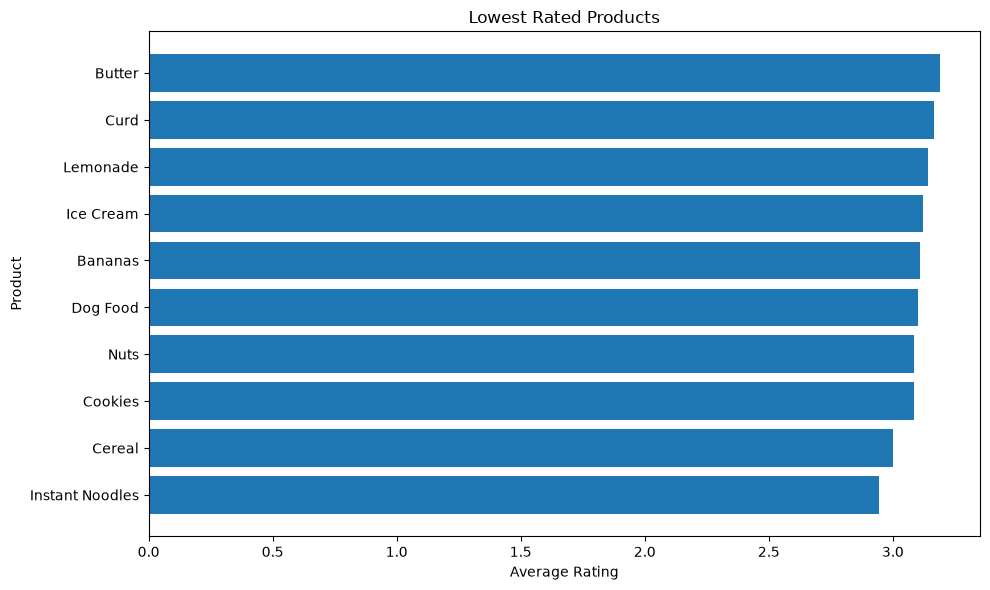

In [120]:
# Visualization for customer feedback and it's relationship with low demand of certain products
plt.figure(figsize=(10,6))

plt.barh(
    worst_ratings.index,
    worst_ratings["Average Rating"]
)

plt.title("Lowest Rated Products")
plt.xlabel("Average Rating")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

In [121]:
# Business Insight: Products with a large no. of customer reviews provide more reliable indicators of customer satisfaction.
# While some products have slightly lower average ratings, these ratings are supported by more than the average number of reviews, 
# suggesting consistent customer experience rather than isolated complaints.

# These products should be prioritized for further investigation by analyzing customer sentiments and feedback comments to identify recurring issues

In [122]:
# Ques 5.4 : What are most common reasons behind consistent dissatisfaction of customer for low demand products?
#The objective is to analyze available feedback dataset and find out why are customers dissatified or what are customers complaining about?

In [123]:
negative_feedback = feedback_product[feedback_product["sentiment"] == "Negative"]
# print(negative_feedback.head())

negative_category = negative_feedback.groupby("feedback_category").size() #complaint category 
negative_category = negative_category.sort_values( ascending=False) # which get most complaints??
# print(negative_category)

negative_products = negative_feedback.groupby(["product_name","feedback_category"]).size()
negative_products = negative_products.sort_values( ascending=False)
print(negative_products.head(10))


product_name    feedback_category
Lotion          Product Quality      24
Pet Treats      Product Quality      24
Baby Wipes      Delivery             21
Pet Treats      Customer Service     20
Dish Soap       Product Quality      18
Pet Treats      App Experience       18
Toilet Cleaner  Delivery             17
Cheese          Customer Service     17
Vitamins        Product Quality      17
Lotion          Delivery             16
dtype: int64


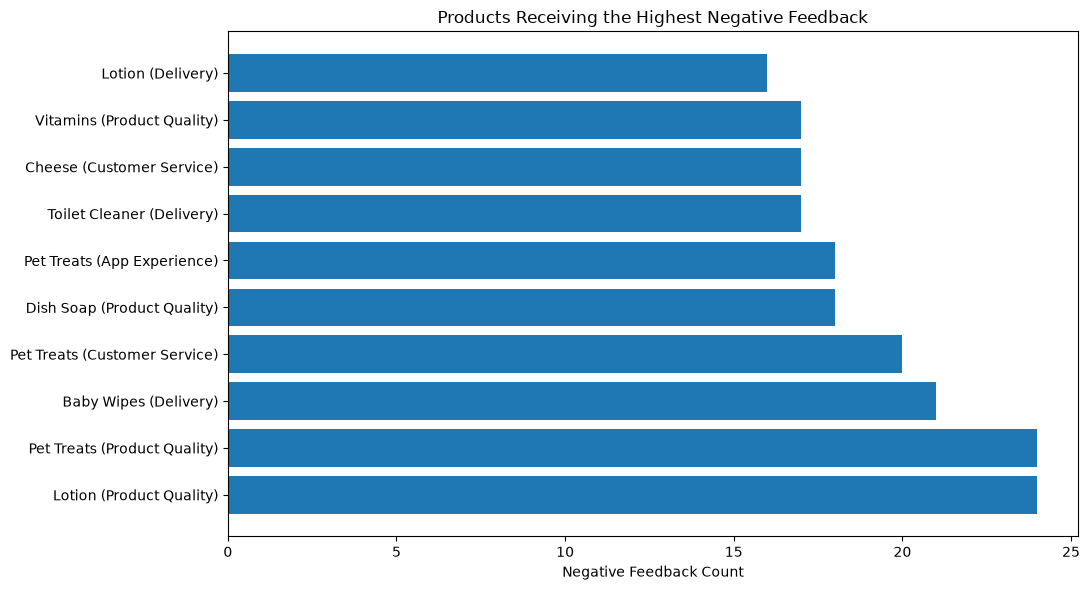

In [124]:
#Visualization for negative feedback and reason behind customer dissatisfaction
top_negative = negative_products.head(10)

plt.figure(figsize=(11,6))

plt.barh(
    [f"{p} ({c})" for p, c in top_negative.index],
    top_negative.values
)

plt.title("Products Receiving the Highest Negative Feedback")
plt.xlabel("Negative Feedback Count")

plt.tight_layout()
plt.show()

In [125]:
# Business Insight: Analyzing negative feedback by both product and complaint category gives us deeper insights than simply 
# counting the no. of negative reviews.

# Products such as Lotion and Pet Treats receive a large number of 'Product Quality' complaints, suggesting that improvements in product
# quality could significantly improve customer satisfaction.

# On the other hand, products such as Baby Wipes receive more 'Delivery-related' complaints, indicating that issues with the delivery
# partner should be resolved to improve customer experience.

# This analysis enables Blinkit to take targeted corrective actions instead of applying the same solution to every low-performing product.

In [126]:
# Final Business Insight: Compiling all the above analysis of various parameters , it can be said low-demand products should not be discontinued 
# solely because of low sales/demand.

# Inventory analysis shows that several low-demand products have sufficient stock available indicating that poor sales are not
# always caused by inventory shortages.

# Customer feedback analysis highlights Product Quality, Customer Service and Delivery as the most common sources of negative customer experience.

# Products such as Lotion and Pet Treats receive frequent Product Quality complaints, 
# whereas products like Baby Wipes receive comparatively more Delivery-related complaints.

# Blinkit should therefore adopt product-specific strategiesfor improving instead of applying a common solution to every low-performing product.

In [127]:
# Ques. 6: Who are Blinkit's most valuable customers and how can the business retain them?

In [128]:

customers_orders = pd.merge(customers, orders , on='customer_id')
customer_sales = pd.merge(customers_orders, order_items, on='order_id')

In [129]:
#Ques 6.1: Which customer segment contributes the highest revenue? #Premium or Regular 
segment_revenue = customer_sales.groupby('customer_segment').agg({'Revenue':'sum'})
segment_revenue['% Revenue'] = (segment_revenue['Revenue']/segment_revenue['Revenue'].sum())*100

print(segment_revenue.sort_values(by='% Revenue',ascending=False))

                     Revenue  % Revenue
customer_segment                       
Regular           1359265.93  27.336130
Premium           1269991.67  25.540739
Inactive          1188807.01  23.908039
New               1154350.82  23.215092


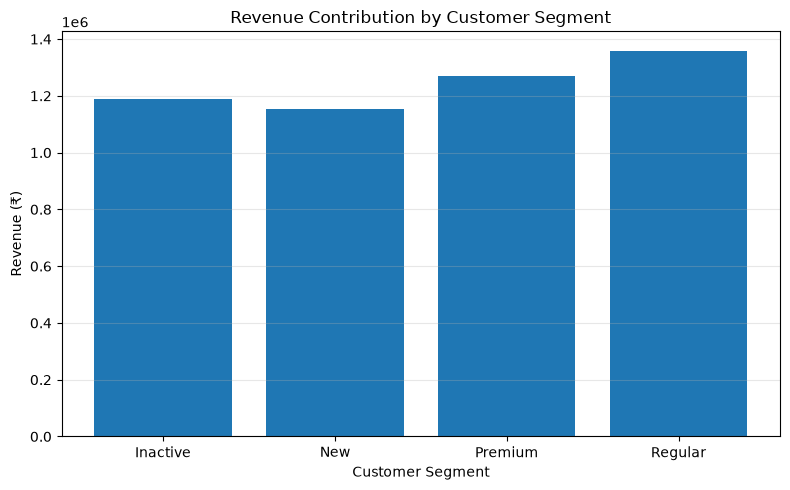

In [130]:
# Visualization for each customer segment's contribution to Revenue
plt.figure(figsize=(8,5))

plt.bar(
    segment_revenue.index,
    segment_revenue["Revenue"]
)

plt.title("Revenue Contribution by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Revenue (₹)")

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [131]:
#Business Insight: From the above table, it can be clearly deduced that Regular contribute to nearly (27%) of the net revenue,
# Premium customers contribute (25%) , New and Inactive customers contribute the least i.e. nearly (23%)

# Since the difference between customer segments is relatively small,Blinkit's revenue is well distributed and does not rely heavily on
# a single customer segment.

# Further analysis of average order value and purchasing behaviour
# is required to understand whether Premium customers spend more
# per order despite contributing a similar share of revenue.

In [132]:
#Ques 6.2: Why Regular customer contribute the most to Revenue, is it because of many small orders? 
#          Do Premium customers spend more per order than other customer segments? 

In [133]:
segment_orders1 = customers_orders.groupby('customer_segment').agg({'avg_order_value':'mean','total_orders':['sum','mean']})
print(segment_orders1)

                 avg_order_value total_orders           
                            mean          sum       mean
customer_segment                                        
Inactive             1083.198899        12562  10.556303
New                  1117.869386        13189  10.792962
Premium              1098.283218        13019  10.267350
Regular              1071.219712        13641  10.334091


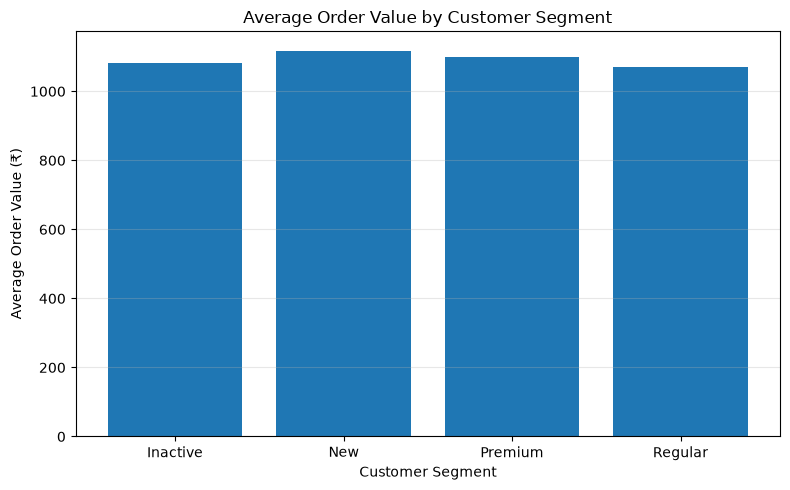

In [134]:
#Visualization for average order value and total orders for each customer segment
plt.figure(figsize=(8,5))

plt.bar(
    segment_orders1.index,
    segment_orders1["avg_order_value"]["mean"]
)

plt.title("Average Order Value by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Order Value (₹)")

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [135]:
# Business Insight: The average order value and average orders per customer are very similar across all customer segments.
# Regular customers generated the highest overall revenue mainly because they contributed the highest total number of orders.
# This indicates that Blinkit's revenue is driven more by maintaining a large active customer base (more orders)
# than by significantly increasing customer spending per order.

In [136]:
# Ques.7: Does delivery performance enhance customer experience?

In [137]:
customer_feedbaack = pd.read_csv('../Data/Blinkit_customer_feedback.csv')
delivery_performance = pd.read_csv('../Data/blinkit_delivery_performance.csv')


In [138]:
# Merge
delivery_summary = pd.merge(delivery_performance, customer_feedbaack, on='order_id')

# Filter
delivery_feedback = delivery_summary[delivery_summary["feedback_category"] == "Delivery"]
delivery_rating = delivery_feedback["rating"].mean()
delivery_sentiment = delivery_feedback.groupby("sentiment").size()

status_rating = delivery_feedback.groupby("delivery_status").agg({"rating":"mean", "feedback_id":"count"})

status_rating.columns = ["Average Rating","Total Feedback"]

# Reasons for delayed deliveries
delay_reason = delivery_feedback.groupby("reasons_if_delayed").size()
delay_reason = delay_reason.sort_values(ascending=False)

# Display Results
print(delay_reason)
print(delivery_feedback.head())
print(f"Average Delivery Rating : {delivery_rating:.2f}")
print(delivery_sentiment)
print(status_rating)


reasons_if_delayed
Traffic    773
dtype: int64
      order_id  delivery_partner_id        promised_time          actual_time  \
0   1961864118                63230  2024-07-17 08:52:01  2024-07-17 08:47:01   
4   5427684290                84315  2023-11-20 05:17:39  2023-11-20 05:18:39   
8   6006693867                91362  2023-07-14 00:02:36  2023-07-14 00:05:36   
10  4455336265                64046  2023-08-30 19:47:06  2023-08-30 19:45:06   
11  3539286337                94899  2023-04-25 20:44:24  2023-04-25 20:39:24   

    delivery_time_minutes  distance_km delivery_status reasons_if_delayed  \
0                    -5.0         0.96         On Time                NaN   
4                     1.0         2.63         On Time            Traffic   
8                     3.0         3.38         On Time            Traffic   
10                   -2.0         0.76         On Time                NaN   
11                   -5.0         3.68         On Time                NaN   

   

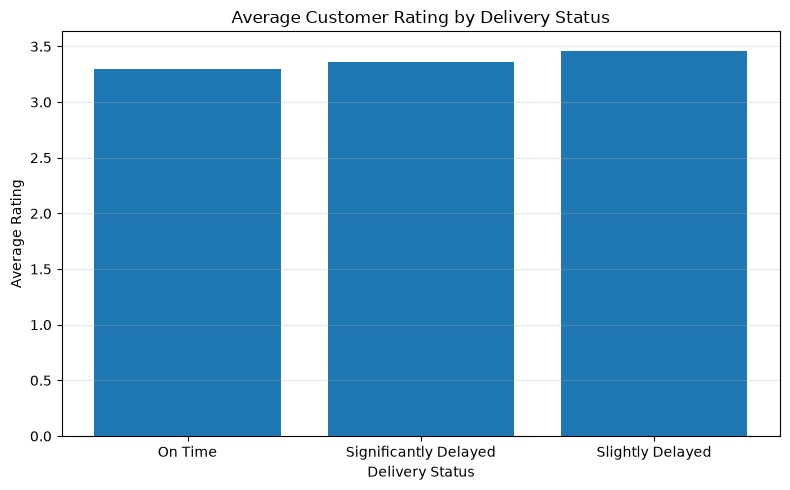

In [139]:
# Visualization for Customer rating by delivery status
plt.figure(figsize=(8,5))

plt.bar(
    status_rating.index,
    status_rating["Average Rating"]
)

plt.title("Average Customer Rating by Delivery Status")
plt.xlabel("Delivery Status")
plt.ylabel("Average Rating")

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

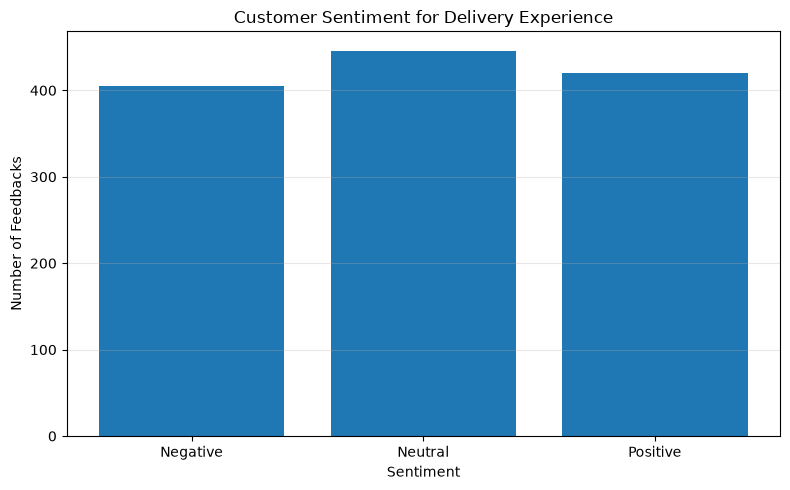

In [140]:
# Visualization for Delivery Feedback Sentiment
plt.figure(figsize=(8,5))

plt.bar(
    delivery_sentiment.index,
    delivery_sentiment.values
)

plt.title("Customer Sentiment for Delivery Experience")
plt.xlabel("Sentiment")
plt.ylabel("Number of Feedbacks")

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [141]:
# Business Insight: Delivery-related feedback has an average rating of approximately 3.33,indicating a generally neutral customer experience.

# Traffic is the primary recorded reason behind delayed deliveries in the available dataset.

# However, customer ratings remain fairly similar across On-Time, Slightly Delayed, and Significantly Delayed deliveries. 
# This suggests that delivery delays alone may not be the primary factor influencing customer satisfaction in this dataset. 
# Other factors such as product quality or order accuracy may also play an important role.

In [142]:
# Ques. 8 : Marketing Campaign Analysis

# Ques 8.1: Which marketing campaigns generate the highest business value?

In [143]:
marketing_performance = pd.read_csv('../Data/blinkit_marketing_performance.csv')
# print(marketing_performance)

In [144]:
campaign_revenue = marketing_performance.groupby('campaign_name').agg({'revenue_generated':'sum'})
print(campaign_revenue.sort_values(by = 'revenue_generated', ascending=False))

                       revenue_generated
campaign_name                           
Referral Program              3691382.60
New User Discount             3603860.17
Email Campaign                3601785.22
Category Promotion            3582455.37
Weekend Special               3571451.83
Flash Sale                    3556087.02
App Push Notification         3554370.00
Membership Drive              3524951.25
Festival Offer                3507063.91


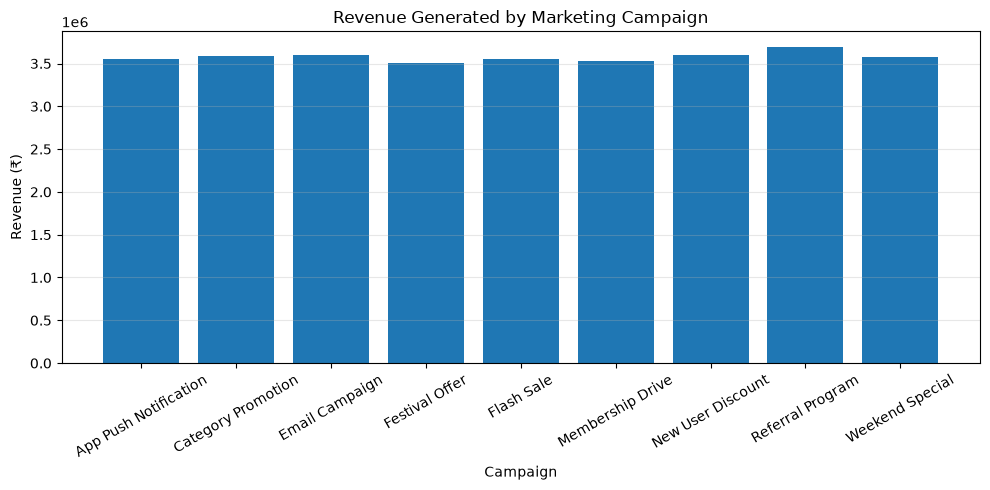

In [145]:
#Visualization for campaigns generating maximum revenue
plt.figure(figsize=(10,5))

plt.bar(
    campaign_revenue.index,
    campaign_revenue["revenue_generated"]
)

plt.title("Revenue Generated by Marketing Campaign")
plt.xlabel("Campaign")
plt.ylabel("Revenue (₹)")

plt.xticks(rotation=30)

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [146]:
# Business Insight:Revenue generated across campaigns is fairly balanced.
# Although the Referral Program generated the highest revenue,the difference between campaigns is relatively small,
# indicating that no single campaign dominates revenue generation.
# Further Analysis is needed to determine which marketing campaign performed best.

In [147]:
# Ques 8.2: Which campaign delivers the highest Return on Ad Spend (ROAS)?

In [148]:
campaign_roas = marketing_performance.groupby("campaign_name").agg({"roas":"mean"})
campaign_roas = campaign_roas.sort_values(by="roas",ascending=False)
print(campaign_roas)

                           roas
campaign_name                  
Email Campaign         2.777067
Festival Offer         2.765917
App Push Notification  2.760817
New User Discount      2.754950
Referral Program       2.743450
Weekend Special        2.743333
Membership Drive       2.719833
Flash Sale             2.711067
Category Promotion     2.689967


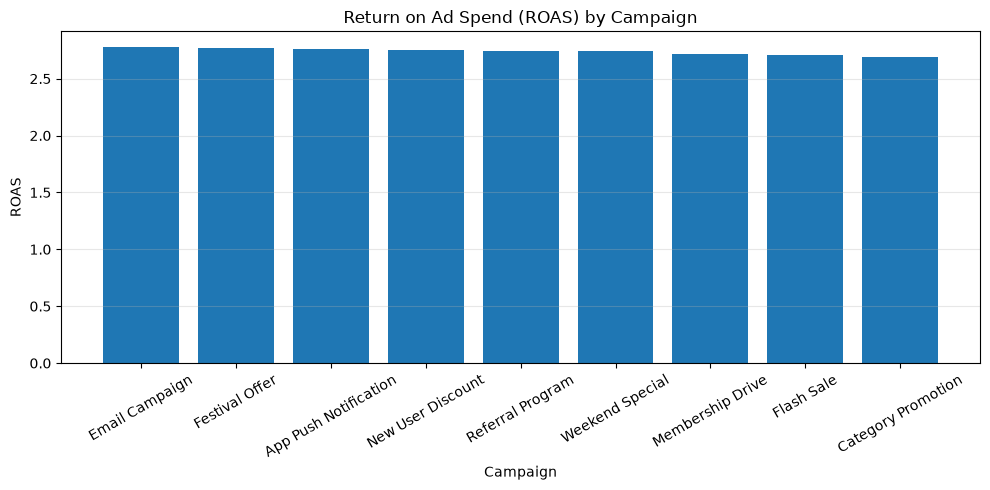

In [149]:
# Visualization for Campaigns delivering highest ROAS
plt.figure(figsize=(10,5))

plt.bar(
    campaign_roas.index,
    campaign_roas["roas"]
)

plt.title("Return on Ad Spend (ROAS) by Campaign")
plt.xlabel("Campaign")
plt.ylabel("ROAS")

plt.xticks(rotation=30)

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [150]:
# Business Insight: The Referral Program generated the highest overall revenue but Email Campaign achieved the highest average ROAS.

# This indicates that although Referral Program contributes more total sales, Email Campaign utilizes the marketing budget more efficiently 
# and generates greater revenue.
#
# Blinkit should continue investing in high-revenue campaigns while studying the strategies used in Email Campaign to
# improve the efficiency of other campaigns.

In [151]:
# Ques 8.3: Which campaigns attracted the most customer attention?

In [152]:
campaign_attention = marketing_performance.groupby("campaign_name").agg({"impressions":"sum","clicks":"sum"})

campaign_attention = campaign_attention.sort_values( by="impressions", ascending=False)
print(campaign_attention)

                       impressions  clicks
campaign_name                             
Membership Drive           3333717  335842
Category Promotion         3323234  329690
Festival Offer             3306651  325928
Email Campaign             3292685  338600
Weekend Special            3290521  323668
Referral Program           3276426  329302
New User Discount          3270347  332400
Flash Sale                 3264022  332882
App Push Notification      3130007  325833


In [153]:
# Click through rate
campaign_attention['CTR'] =  (campaign_attention['clicks']/campaign_attention['impressions'])*100
print(campaign_attention.sort_values(by= 'CTR', ascending=False))

                       impressions  clicks        CTR
campaign_name                                        
App Push Notification      3130007  325833  10.409977
Email Campaign             3292685  338600  10.283401
Flash Sale                 3264022  332882  10.198522
New User Discount          3270347  332400  10.164059
Membership Drive           3333717  335842  10.074100
Referral Program           3276426  329302  10.050647
Category Promotion         3323234  329690   9.920758
Festival Offer             3306651  325928   9.856740
Weekend Special            3290521  323668   9.836375


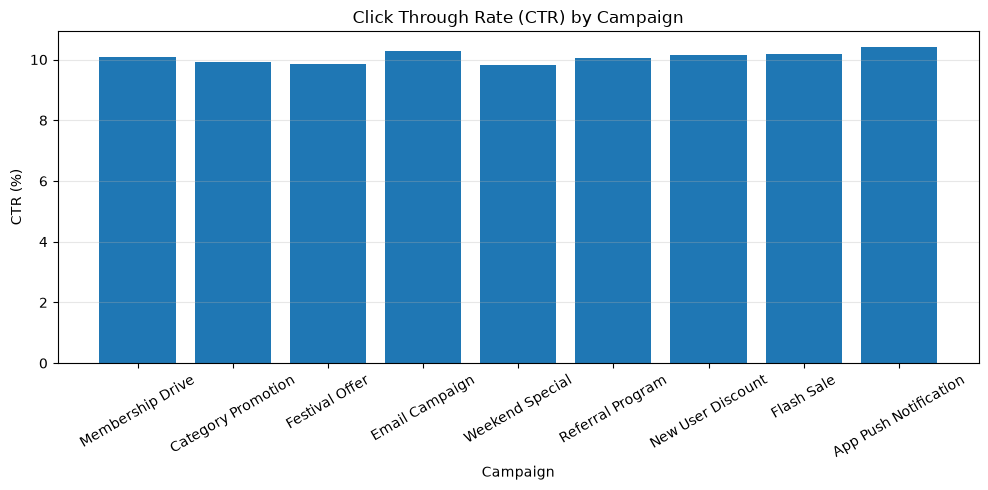

In [154]:
# Visualization for CTR
plt.figure(figsize=(10,5))

plt.bar(
    campaign_attention.index,
    campaign_attention["CTR"]
)

plt.title("Click Through Rate (CTR) by Campaign")
plt.xlabel("Campaign")
plt.ylabel("CTR (%)")

plt.xticks(rotation=30)

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [155]:
# Business Insight: The Click Through Rate (CTR) across all campaigns is relatively consistent and ranging between approximately 9.8% and 10.4%.

# App Push Notification achieved the highest CTR indicating that it attracted the highest no. of user clicks relative to impressions.

# However, the small variation in CTR suggests that campaign engagement remains fairly balanced across different marketing campaigns.

In [156]:
#Ques 8.4: How many customers converted after clicking?

In [157]:
campaign_conversions = marketing_performance.groupby('campaign_name').agg({'clicks':'sum','conversions':'sum'})
campaign_conversions['conversion_rate'] = (campaign_conversions['conversions']/campaign_conversions['clicks'])*100
print(campaign_conversions.sort_values(by='conversion_rate',ascending=False))

                       clicks  conversions  conversion_rate
campaign_name                                              
Weekend Special        323668        33271        10.279360
New User Discount      332400        33964        10.217810
Category Promotion     329690        33568        10.181686
Referral Program       329302        33490        10.169996
App Push Notification  325833        32783        10.061289
Festival Offer         325928        32765        10.052834
Flash Sale             332882        33211         9.976809
Membership Drive       335842        32550         9.692058
Email Campaign         338600        32436         9.579445


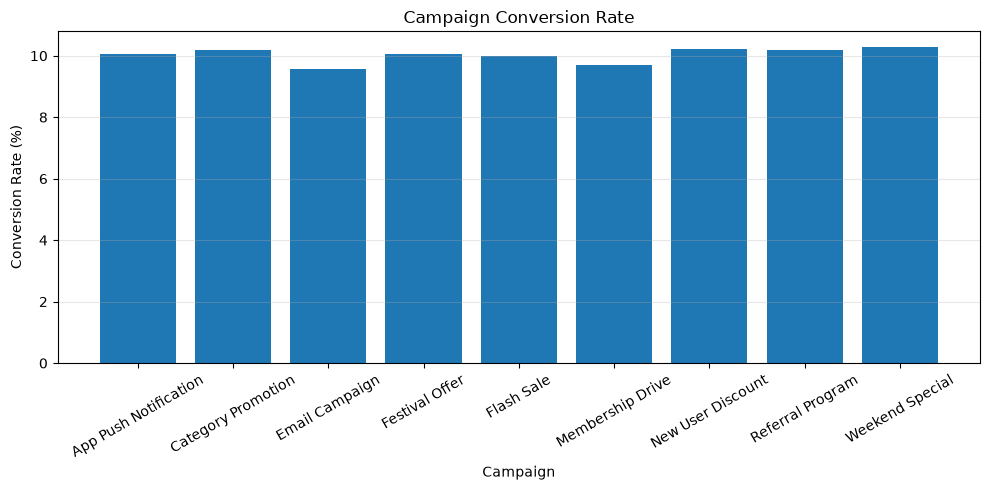

In [158]:
# Visualization for conversion rates of each campaign
plt.figure(figsize=(10,5))

plt.bar(
    campaign_conversions.index,
    campaign_conversions["conversion_rate"]
)

plt.title("Campaign Conversion Rate")
plt.xlabel("Campaign")
plt.ylabel("Conversion Rate (%)")

plt.xticks(rotation=30)

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [159]:
# Business Insight: Weekend Special achieved the highest Conversion Rate (~10.28%),indicating that it converted interested party
# into customers more effectively than the other campaigns.

# Although App Push Notification generated the highest CTR,it did not achieve the highest Conversion Rate,
# suggesting that attracting clicks alone does not necessarily translate into higher customer conversions.
#
# Similarly, Referral Program generated the highest overall revenue, whereas Email Campaign achieved the highest ROAS,
# highlighting that different campaigns excel at different stages of the marketing funnel. 

In [160]:
# Ques 8.5: Should Blinkit increase or decrease marketing spend?

In [161]:
campaign_spend = marketing_performance.groupby("campaign_name").agg({"spend":"sum","revenue_generated":"sum"})
campaign_spend = campaign_spend.sort_values(by="spend",ascending=False)

print(campaign_spend)

                            spend  revenue_generated
campaign_name                                       
Category Promotion     1850583.00         3582455.37
New User Discount      1833454.81         3603860.17
Flash Sale             1831687.82         3556087.02
Referral Program       1818025.51         3691382.60
Email Campaign         1810729.67         3601785.22
Weekend Special        1799611.29         3571451.83
Festival Offer         1796687.14         3507063.91
Membership Drive       1790069.80         3524951.25
App Push Notification  1788989.20         3554370.00


In [162]:
campaign_spend["Profit"] = (campaign_spend["revenue_generated"]- campaign_spend["spend"])
print(campaign_spend.sort_values(by='Profit', ascending=False))


                            spend  revenue_generated      Profit
campaign_name                                                   
Referral Program       1818025.51         3691382.60  1873357.09
Email Campaign         1810729.67         3601785.22  1791055.55
Weekend Special        1799611.29         3571451.83  1771840.54
New User Discount      1833454.81         3603860.17  1770405.36
App Push Notification  1788989.20         3554370.00  1765380.80
Membership Drive       1790069.80         3524951.25  1734881.45
Category Promotion     1850583.00         3582455.37  1731872.37
Flash Sale             1831687.82         3556087.02  1724399.20
Festival Offer         1796687.14         3507063.91  1710376.77


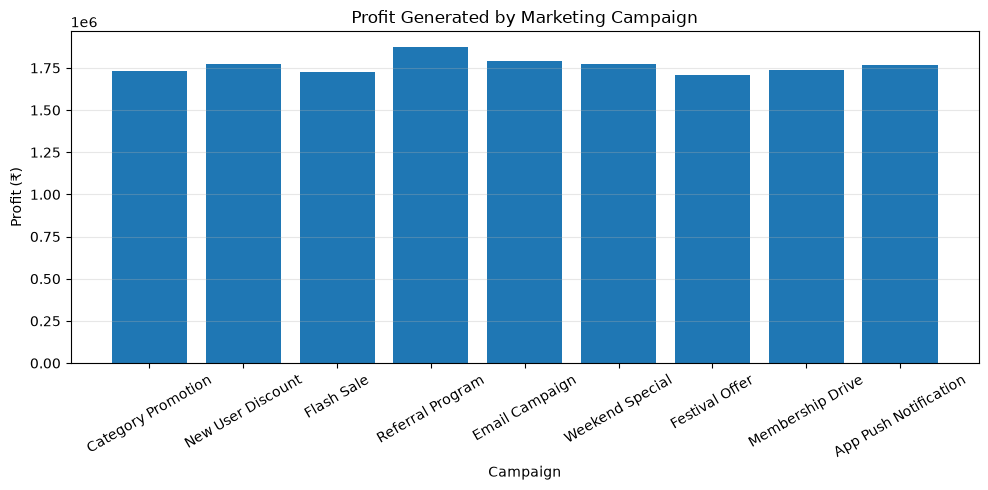

In [163]:
# Visualization for profit generated by each campaign
plt.figure(figsize=(10,5))

plt.bar(
    campaign_spend.index,
    campaign_spend["Profit"]
)

plt.title("Profit Generated by Marketing Campaign")
plt.xlabel("Campaign")
plt.ylabel("Profit (₹)")

plt.xticks(rotation=30)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [164]:
# Business Insight: Referral Program generated the highest overall profit among all marketing campaigns making it the most valuable campaign from a
# business perspective.

# Even though the campaign spending is fairly similar across all campaigns differences in revenue generation lead to noticeable differences
# in profitability.

# Blinkit should continue investing in high-profit campaigns while evaluating lower-performing campaigns for optimization.